## Data Modeling
This notebook includes the data modeling steps in the solar energy project. <br>
As inputs it requires the cleaned, encoded, re-sampled, and scaled data frames X_train, X_test, y_train, y_test. <br>
The objective is to test different models

In [11]:
# all in one code
import pandas as pd
path = r"..\data\processed\\" # for Manuel
# path = "~/dec24_bds_solar_energy/data/processed/" # for Eren

# Data collection

# Import os_minmax
#X_train = pd.read_csv(path+'X_train_os_minmax.csv')
#X_test = pd.read_csv(path+'X_test_minmax.csv')
#y_train = pd.read_csv(path+'y_train_os.csv').squeeze()
#y_test = pd.read_csv(path+'y_test.csv').squeeze()

# Import os_robust (We decided to use oversampling with robust scaling)
X_train = pd.read_csv(path+'X_train_os_robust.csv')
X_test = pd.read_csv(path+'X_test_robust.csv')
y_train = pd.read_csv(path+'y_train_os.csv').squeeze()
y_test = pd.read_csv(path+'y_test.csv').squeeze()

# # Import us_robust
#X_train = pd.read_csv(path+'X_train_us_robust.csv')
#X_test = pd.read_csv(path+'X_test_robust.csv')
#y_train = pd.read_csv(path+'y_train_us.csv').squeeze()
#y_test = pd.read_csv(path+'y_test.csv').squeeze()

# Grid Search
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, make_scorer
param_grids = {
    "RandomForest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    }
}
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "KNN": KNeighborsClassifier()
}
scorer = make_scorer(f1_score, average='binary')
best_models = {}
for name, model in models.items():
    print(f" Tuning {name} for F1-score...")
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring=scorer, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_models[name] = grid_search.best_estimator_
    print(f" Best {name} Params: {grid_search.best_params_}")
    print(f" Best {name} F1-score: {grid_search.best_score_:.4f}\n")

# Evaluate the best models on the test set
print("Final Model Evaluations on Test Data:")
for name, model in best_models.items():
    y_train_pred = model.predict(X_train)
    f1 = f1_score(y_train, y_train_pred)
    print(f" {name} train: F1-score = {f1:.4f}")
    y_test_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_test_pred)
    print(f" {name} test: F1-score = {f1:.4f}")

 Tuning RandomForest for F1-score...
 Best RandomForest Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
 Best RandomForest F1-score: 0.9594

 Tuning SVM for F1-score...
 Best SVM Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
 Best SVM F1-score: 0.9164

 Tuning XGBoost for F1-score...


C:\Users\fscoh\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [05:41:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 Best XGBoost Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
 Best XGBoost F1-score: 0.9551

 Tuning KNN for F1-score...
 Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
 Best KNN F1-score: 0.9431

Final Model Evaluations on Test Data:
 RandomForest train: F1-score = 0.9983
 RandomForest test: F1-score = 0.9390
 SVM train: F1-score = 0.9250
 SVM test: F1-score = 0.9153
 XGBoost train: F1-score = 0.9997
 XGBoost test: F1-score = 0.9299
 KNN train: F1-score = 1.0000
 KNN test: F1-score = 0.9359


### 0. Data collection

In [4]:
import pandas as pd

In [6]:
path = r"..\data\processed\\" # for Manuel
#path = "~/dec24_bds_solar_energy/data/processed/" # for Eren

# X_train = pd.read_csv(path+'X_train_os_minmax.csv')
# X_test = pd.read_csv(path+'X_test_minmax.csv')
# y_train = pd.read_csv(path+'y_train_os.csv')
# y_test = pd.read_csv(path+'y_test.csv')

X_train = pd.read_csv(path+'X_train_os_robust.csv')
X_test = pd.read_csv(path+'X_test_robust.csv')
y_train = pd.read_csv(path+'y_train_os.csv')
y_test = pd.read_csv(path+'y_test.csv')

X_train.shape,y_train.shape

((6064, 11), (6064, 1))

In [7]:
X_train.head(1)

,Acres,Distance to GTET 100,Distance to GTET 200,Distance to CAISO substation,Population Density,Urban or Rural,percentile_GTET100,percentile_GTET200,percentile_CAISO,Parking,Rooftop
0,-0.114639,0.178961,-0.302299,-0.23775,0.453628,0.0,2.0,1.0,1.0,0.0,1.0


### 1. Random Forest Classifier

In [3]:
# Only test-wise I used a baseline model (RandomForestClassifier) to see if the pre-processing was okay (so this notebook cell is just a test):
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Instantiating the model (e.g., RandomForestClassifier) and train the model on the scaled training data (y_train does not need to be scaled since it is binary)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Create predictions
y_pred = model.predict(X_test)

# Evaluate model performance using a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

/tmp/ipykernel_6022/733674338.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(X_train, y_train)


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       322
           1       0.95      0.94      0.94       758

    accuracy                           0.92      1080
   macro avg       0.90      0.91      0.91      1080
weighted avg       0.92      0.92      0.92      1080



### 2. SVM Classifier

In [21]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
# Instantiate the model and train it
#svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model=SVC(C=10, gamma= 'auto', kernel= 'rbf',probability=True)
svm_model.fit(X_train, y_train)

# Create predictions
svm_pred = svm_model.predict(X_test)

# Evaluate model performance using a classification report
svm_report = classification_report(y_test, svm_pred)
print("Classification Report:")
print(svm_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.91      0.83       322
           1       0.96      0.88      0.92       758

    accuracy                           0.89      1080
   macro avg       0.86      0.89      0.87      1080
weighted avg       0.90      0.89      0.89      1080



### 3. XGBoost Classifier

In [6]:
from xgboost import XGBClassifier

# Instantiate the model and train it
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Create predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluate model performance using a classification report
xgb_report = classification_report(y_test, xgb_pred)
print("Classification Report:")
print(xgb_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       322
           1       0.94      0.95      0.94       758

    accuracy                           0.92      1080
   macro avg       0.91      0.90      0.91      1080
weighted avg       0.92      0.92      0.92      1080



### 4. K-Nearest Neighbors Classifier

In [7]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate the model and train it
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Create predictions
knn_pred = knn_model.predict(X_test)

# Evaluate model performance using a classification report
knn_report = classification_report(y_test, knn_pred)
print("Classification Report:")
print(knn_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       322
           1       0.96      0.91      0.93       758

    accuracy                           0.91      1080
   macro avg       0.89      0.91      0.90      1080
weighted avg       0.92      0.91      0.91      1080



/home/ubuntu/dec24_bds_solar_energy/solar_venv/lib/python3.8/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


### GridsearchCV

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, make_scorer

# Define hyperparameter grids for each model
param_grids = {
    "RandomForest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    }
}


In [9]:
# Define models
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "KNN": KNeighborsClassifier()
}
# Use F1-score as the optimization metric
scorer = make_scorer(f1_score, average='binary')

In [8]:
best_models = {}
for name, model in models.items():
    print(f" Tuning {name} for F1-score...")
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring=scorer, n_jobs=-1)
    grid_search.fit(X_train, y_train) # TODO: "X_train_ros"/"y_train_ros" changed to "X_train"/"y_train" because we all decided to use Oversampling with Robust Scaling
    
    best_models[name] = grid_search.best_estimator_
    print(f" Best {name} Params: {grid_search.best_params_}")
    print(f" Best {name} F1-score: {grid_search.best_score_:.4f}\n")

# Evaluate the best models on the test set
print("Final Model Evaluations on Test Data:")
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    print(f" {name}: F1-score = {f1:.4f}")

 Tuning RandomForest for F1-score...


C:\Users\fscoh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


 Best RandomForest Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
 Best RandomForest F1-score: 0.9594

 Tuning SVM for F1-score...


C:\Users\fscoh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


 Best SVM Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
 Best SVM F1-score: 0.9164

 Tuning XGBoost for F1-score...


C:\Users\fscoh\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:57:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 Best XGBoost Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
 Best XGBoost F1-score: 0.9551

 Tuning KNN for F1-score...


C:\Users\fscoh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


 Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
 Best KNN F1-score: 0.9431

Final Model Evaluations on Test Data:
 RandomForest: F1-score = 0.9390
 SVM: F1-score = 0.9153
 XGBoost: F1-score = 0.9299
 KNN: F1-score = 0.9359


In [11]:
print('Best model: Random Forest')
print('Best parameters: {max_depth: None, min_samples_split: 2, n_estimators: 200}')

Best model: Random Forest
Best parameters: {max_depth: None, min_samples_split: 2, n_estimators: 200}


In [12]:
model = RandomForestClassifier(max_depth= None, min_samples_split= 2, n_estimators= 200,random_state=42)
model.fit(X_train, y_train) # TODO: "X_train_ros"/"y_train_ros" changed to "X_train"/"y_train" because we all decided to use Oversampling with Robust Scaling

# Create predictions
y_pred = model.predict(X_test)
y_train_pred=model.predict(X_train) # TODO: "X_train_ros" changed to "X_train" because we all decided to use Oversampling with Robust Scaling
# Evaluate model performance using a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)


/tmp/ipykernel_2340/569549439.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(X_train, y_train) # TODO: "X_train_ros"/"y_train_ros" changed to "X_train"/"y_train" because we all decided to use Oversampling with Robust Scaling


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       322
           1       0.95      0.94      0.94       758

    accuracy                           0.92      1080
   macro avg       0.91      0.91      0.91      1080
weighted avg       0.92      0.92      0.92      1080



In [13]:
#confusion matrix
from sklearn.metrics import confusion_matrix
cm_test=confusion_matrix(y_test, y_pred)
cm_train=confusion_matrix(y_train, y_train_pred) # TODO: "X_train_ros" changed to "X_train" because we all decided to use Oversampling with Robust Scaling
print('confusion matrix for test set')
print(cm_test)
print('confusion matrix for train set')
print(cm_train)

confusion matrix for test set
[[282  40]
 [ 44 714]]
confusion matrix for train set
[[3032    0]
 [   0 3032]]


In [14]:
#f1 score
f1_score_test=f1_score(y_test, y_pred)
f1_score_train=f1_score(y_train, y_train_pred) # TODO: "X_train_ros" changed to "X_train" because we all decided to use Oversampling with Robust Scaling
print('f1_score_test =',f1_score_test)
print('f1_score_train =',f1_score_train)

f1_score_test = 0.9444444444444445
f1_score_train = 1.0


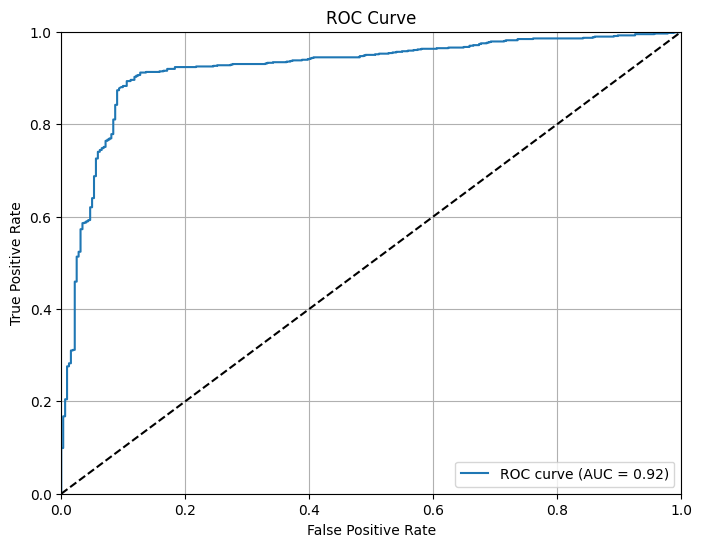


Computing SHAP values...


  0%|          | 0/1080 [00:00<?, ?it/s]

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import roc_auc_score, roc_curve

# ROC Curve Plot for the SVC model
y_pred_proba_test = svm_model.predict_proba(X_test)[:, 1] # We decided for the SVC model
test_roc_auc = roc_auc_score(y_test, y_pred_proba_test)

plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_test)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {test_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0, 1) # Sets the limits for both axes to focus on the range [0, 1]
plt.ylim(0, 1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# SHAP Analysis for the SVC model (skip for testing)
print("\nComputing SHAP values...")

# Use K-means clustering to reduce the number of background samples to 10 (takes 45 minutes!; reduce to 1 if it should be faster!)
background_data = shap.kmeans(X_train, 10) # reduce to 1 to make it faster

# Create the SHAP explainer with the reduced background data
explainer = shap.KernelExplainer(svm_model.predict_proba, background_data) # instead of: explainer = shap.KernelExplainer(svm_model.predict_proba, X_train)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot (for model interpretability)
shap.summary_plot(shap_values[1], X_test)  # For class 1 (modify based on your model output)


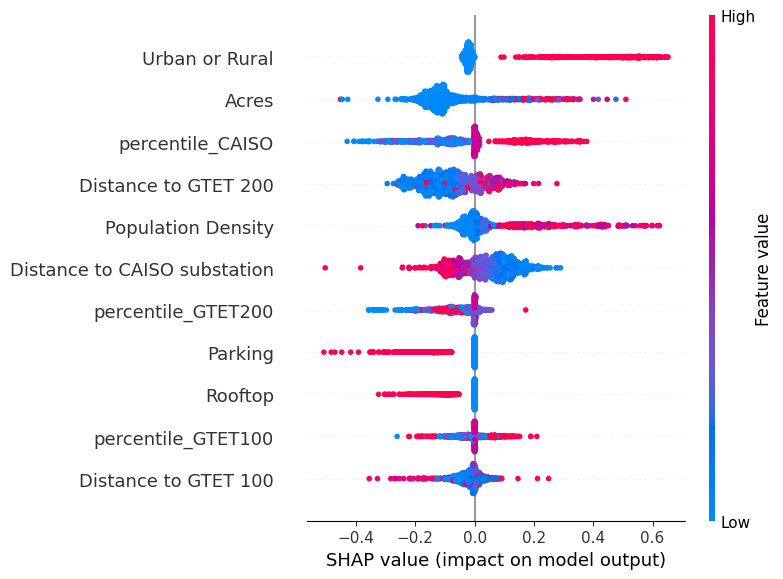

In [46]:

# SHAP Summary Plot (for model interpretability)
shap.summary_plot(shap_values[:,:,0], X_test)
#print(shap_values[:,:,0].shape)
#X_test.shape

### Deep Learning tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model=Sequential()
model.add(Dense(units=10,activation='tanh',input_shape=(11,)))
model.add(Dense(units=8,activation='tanh'))
model.add(Dense(units=6,activation='tanh'))
model.add(Dense(units=3,activation='softmax'))

In [ ]:
model.summary()

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history = model.fit(X_train_ros, y_train_ros, epochs=500, batch_size=32, validation_split=0.1)

In [ ]:
test_pred = model.predict(X_test)

In [ ]:
y_test_class = y_test
y_pred_class = np.argmax(test_pred, axis=1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_class, y_pred_class))
sns.heatmap(confusion_matrix(y_test_class, y_pred_class), cmap='Blues', cbar=False, annot=True)